# DoubleML Tutorial 00: Environment And Library Tour

This notebook starts the DoubleML tutorial series. It is intentionally more theoretical than a quick API demo because DoubleML is not just another prediction package. It is a framework for causal effect estimation when the identifying assumptions are supplied by the analyst and flexible machine-learning models are used for nuisance adjustment.

The key idea is double / debiased machine learning. We want to estimate a causal parameter such as an average treatment effect or a partially linear treatment effect. At the same time, we may need high-dimensional or nonlinear models for nuisance functions such as outcome regression, treatment regression, propensity scores, or instrument first stages. Naively plugging flexible machine-learning predictions into a causal estimator can create regularization bias. DoubleML reduces that problem by using Neyman-orthogonal score functions and cross-fitting.

In plain language:

- the causal design says what effect is identifiable;
- the nuisance learners estimate the adjustment functions needed by that design;
- orthogonal scores make the final estimate less sensitive to small nuisance-model errors;
- cross-fitting keeps each observation's nuisance prediction out of the model that was trained on that observation;
- inference then attaches standard errors, confidence intervals, and hypothesis tests to the effect estimate.

Estimated runtime: less than 1 minute on a typical laptop.

## Learning Goals

By the end of this notebook, you should be able to:

- explain the difference between causal identification and machine-learning nuisance estimation;
- describe why DoubleML uses orthogonal scores and cross-fitting;
- recognize the main DoubleML data containers and model classes;
- build a small `DoubleMLData` object;
- fit a minimal `DoubleMLPLR` model and read its output;
- understand the role of the later notebooks in this tutorial series.

## Where DoubleML Fits

DoubleML belongs in the causal effect-estimation part of the workflow. It does not discover a causal graph for you. It also does not make unconfoundedness, instrument validity, parallel trends, or selection assumptions true. Those assumptions come from the study design.

A useful way to place it is:

1. Formulate a causal question.
2. Choose an identification strategy: unconfoundedness, IV, DID, RDD, sample selection, or another design.
3. Define the estimand: ATE, ATT, LATE, PLR coefficient, GATE, QTE, and so on.
4. Use DoubleML to estimate the identified parameter with flexible nuisance models and valid uncertainty quantification.
5. Stress-test the result with diagnostics, sensitivity checks, and design-specific caveats.

This first notebook focuses on steps 3 and 4 at a high level. The later notebooks go deeper model by model.

## Setup

This cell imports the scientific Python stack, prepares output folders, configures Matplotlib to write cache files inside the repository, and imports DoubleML. Keeping the setup explicit makes the notebook easier to rerun from different working directories.

In [1]:
from pathlib import Path
import inspect
import os
import warnings

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "doubleml":
    PROJECT_ROOT = PROJECT_ROOT.parents[2]

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "doubleml" / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"
MATPLOTLIB_CACHE_DIR = OUTPUT_DIR / "matplotlib_cache"

for directory in [DATASET_DIR, FIGURE_DIR, TABLE_DIR, REPORT_DIR, MATPLOTLIB_CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CACHE_DIR))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from IPython.display import display

import doubleml as dml
import doubleml.datasets as dml_datasets
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

NOTEBOOK_PREFIX = "00"
RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

print(f"Project root: {PROJECT_ROOT}")
print(f"Output folder: {OUTPUT_DIR}")
print(f"DoubleML version: {getattr(dml, '__version__', 'not exposed')}")

Project root: /home/apex/Documents/ranking_sys
Output folder: /home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs
DoubleML version: 0.11.2


The environment is now ready. The notebook saves every generated table and figure with the `00_` prefix so outputs from different tutorial notebooks do not collide.

## Package Versions

Version logging is boring until it saves you. DoubleML analysis depends on the DoubleML package, the learners passed into it, and the numerical stack underneath. This cell records the package versions used in the run.

In [2]:
from importlib import metadata

packages = [
    "doubleml",
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "statsmodels",
    "lightgbm",
    "xgboost",
]
version_rows = []
for package in packages:
    try:
        version = metadata.version(package)
        status = "installed"
    except metadata.PackageNotFoundError:
        version = None
        status = "missing"
    version_rows.append({"package": package, "status": status, "version": version})

version_table = pd.DataFrame(version_rows)
version_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(version_table)

,package,status,version
0,doubleml,installed,0.11.2
1,numpy,installed,2.4.4
2,pandas,installed,3.0.2
3,scipy,installed,1.17.1
4,scikit-learn,installed,1.6.1
5,matplotlib,installed,3.10.9
6,seaborn,installed,0.13.2
7,statsmodels,installed,0.14.6
8,lightgbm,installed,4.6.0
9,xgboost,installed,3.2.0


The important line for this tutorial is `doubleml`. Tree learners such as LightGBM and XGBoost are useful in later notebooks, but the first executable example below uses scikit-learn random forests so it stays simple and reproducible.

## Theory: What Problem Does DoubleML Solve?

Suppose we observe outcome `Y`, treatment `D`, and controls `X`. A common causal target is the effect of `D` on `Y` after adjusting for `X`. If `X` is high-dimensional or the adjustment functions are nonlinear, we may want machine learning to estimate those adjustment functions.

The problem is that machine-learning predictions are regularized, tuned, and estimated from data. If we plug them into a causal estimator too directly, the final causal estimate can inherit first-order bias from nuisance-model errors.

DoubleML solves this by combining two ideas:

- **Neyman orthogonality:** construct a score where small first-stage nuisance errors have only second-order impact on the target parameter.
- **Cross-fitting:** estimate nuisance functions on one fold and evaluate their predictions on held-out observations, so the final score uses out-of-sample nuisance predictions.

For the partially linear regression model, a simplified structural form is:

$$
Y = \theta_0 D + g_0(X) + \varepsilon, \quad E[\varepsilon \mid X, D] = 0
$$

and the treatment equation is:

$$
D = m_0(X) + V, \quad E[V \mid X] = 0.
$$

Here `g_0(X)` and `m_0(X)` are nuisance functions. The causal parameter of interest is `theta_0`, not the prediction model itself.

The next table turns the notation into a reusable glossary. This is worth doing early because DoubleML object names (`ml_l`, `ml_m`, `ml_g`, `ml_r`) are compact and can feel cryptic before the roles are clear.

In [3]:
theory_glossary = pd.DataFrame(
    [
        {
            "term": "target parameter",
            "symbol_or_name": "theta",
            "meaning": "The causal effect or causal estimand we want to estimate.",
            "example_in_plr": "Effect of treatment d on outcome y after adjusting for x.",
        },
        {
            "term": "outcome nuisance function",
            "symbol_or_name": "l(X) or g(X)",
            "meaning": "A prediction function for the outcome component explained by controls.",
            "example_in_plr": "Predict y from x.",
        },
        {
            "term": "treatment nuisance function",
            "symbol_or_name": "m(X)",
            "meaning": "A prediction function for treatment assignment or treatment intensity explained by controls.",
            "example_in_plr": "Predict d from x.",
        },
        {
            "term": "orthogonal score",
            "symbol_or_name": "psi(W; theta, eta)",
            "meaning": "A moment equation designed to be insensitive to small nuisance errors around the truth.",
            "example_in_plr": "Use residualized outcome and residualized treatment.",
        },
        {
            "term": "cross-fitting",
            "symbol_or_name": "K-fold nuisance prediction",
            "meaning": "Fit nuisance learners on training folds and predict nuisance values on held-out folds.",
            "example_in_plr": "Each row gets out-of-fold predictions for y and d.",
        },
        {
            "term": "nuisance learner",
            "symbol_or_name": "ml_l, ml_m, ml_g, ml_r",
            "meaning": "A machine-learning model used to estimate a nuisance function, not the final causal target directly.",
            "example_in_plr": "Random forest, Lasso, boosting, or another sklearn-style estimator.",
        },
    ]
)
theory_glossary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_theory_glossary.csv", index=False)
display(theory_glossary)

,term,symbol_or_name,meaning,example_in_plr
0,target parameter,theta,The causal effect or causal estimand we want t...,Effect of treatment d on outcome y after adjus...
1,outcome nuisance function,l(X) or g(X),A prediction function for the outcome componen...,Predict y from x.
2,treatment nuisance function,m(X),A prediction function for treatment assignment...,Predict d from x.
3,orthogonal score,"psi(W; theta, eta)",A moment equation designed to be insensitive t...,Use residualized outcome and residualized trea...
4,cross-fitting,K-fold nuisance prediction,Fit nuisance learners on training folds and pr...,Each row gets out-of-fold predictions for y an...
5,nuisance learner,"ml_l, ml_m, ml_g, ml_r",A machine-learning model used to estimate a nu...,"Random forest, Lasso, boosting, or another skl..."


The glossary makes one conceptual boundary clear: nuisance models are helpers. They may be sophisticated predictors, but the final object of interest is still the causal parameter and its uncertainty.

## Visual Workflow

This figure summarizes the DoubleML workflow. We start with a causal design and a structured dataset, pass learner objects into a model class, let DoubleML create cross-fitted nuisance predictions, solve the orthogonal score, and then report estimates with uncertainty and caveats.

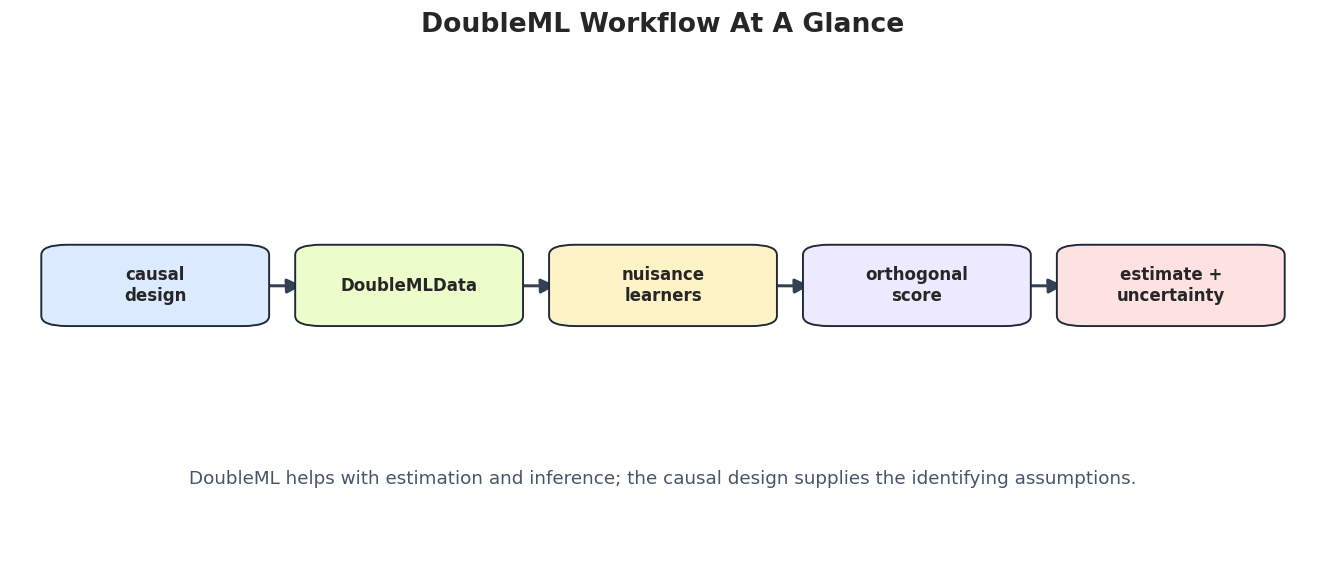

In [4]:
def draw_workflow_box(ax, center, label, color):
    x, y = center
    width, height = 0.135, 0.12
    box = FancyBboxPatch(
        (x - width / 2, y - height / 2),
        width,
        height,
        boxstyle="round,pad=0.02",
        facecolor=color,
        edgecolor="#1f2937",
        linewidth=1.15,
        zorder=3,
    )
    ax.add_patch(box)
    ax.text(x, y, label, ha="center", va="center", fontsize=10, fontweight="bold", zorder=4)


def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.8,
        color="#334155",
        connectionstyle="arc3,rad=0.02",
        zorder=2,
    )
    ax.add_patch(arrow)

workflow_nodes = [
    ((0.11, 0.56), "causal\ndesign", "#dbeafe"),
    ((0.305, 0.56), "DoubleMLData", "#ecfccb"),
    ((0.50, 0.56), "nuisance\nlearners", "#fef3c7"),
    ((0.695, 0.56), "orthogonal\nscore", "#ede9fe"),
    ((0.89, 0.56), "estimate +\nuncertainty", "#fee2e2"),
]

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

for center, label, color in workflow_nodes:
    draw_workflow_box(ax, center, label, color)
for left, right in zip(workflow_nodes[:-1], workflow_nodes[1:]):
    draw_arrow(ax, (left[0][0] + 0.080, left[0][1]), (right[0][0] - 0.080, right[0][1]))

ax.text(
    0.5,
    0.18,
    "DoubleML helps with estimation and inference; the causal design supplies the identifying assumptions.",
    ha="center",
    va="center",
    fontsize=11,
    color="#475569",
)
ax.set_title("DoubleML Workflow At A Glance", pad=18, fontsize=16, fontweight="bold")
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_doubleml_workflow.png", dpi=160, bbox_inches="tight")
plt.show()

The central warning is in the caption: DoubleML is not a substitute for a design. It gives a principled estimation engine once the design and estimand are defensible.

## Core Object Tour

DoubleML uses a small set of recurring object types. The most important split is between data containers and model classes.

- Data containers define which columns are outcome, treatment, controls, instruments, clusters, panels, or design-specific variables.
- Model classes define the causal score, nuisance roles, resampling, and inference procedure.
- Learners are ordinary scikit-learn-style estimators that DoubleML clones and fits inside cross-fitting.

The next cell introspects the installed DoubleML version so the class list reflects this exact environment.

In [5]:
core_class_names = [
    "DoubleMLData",
    "DoubleMLClusterData",
    "DoubleMLPanelData",
    "DoubleMLDIDData",
    "DoubleMLRDDData",
    "DoubleMLSSMData",
    "DoubleMLPLR",
    "DoubleMLPLIV",
    "DoubleMLIRM",
    "DoubleMLIIVM",
    "DoubleMLDID",
    "DoubleMLDIDCS",
    "DoubleMLSSM",
    "DoubleMLAPO",
    "DoubleMLAPOS",
    "DoubleMLQTE",
    "DoubleMLCVAR",
    "DoubleMLBLP",
    "DoubleMLPolicyTree",
]

class_rows = []
for class_name in core_class_names:
    if hasattr(dml, class_name):
        cls = getattr(dml, class_name)
        try:
            signature = str(inspect.signature(cls))
        except (TypeError, ValueError):
            signature = "signature not available"
        class_rows.append(
            {
                "class_name": class_name,
                "available": True,
                "signature": signature,
            }
        )
    else:
        class_rows.append({"class_name": class_name, "available": False, "signature": None})

class_table = pd.DataFrame(class_rows)
class_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_core_class_signatures.csv", index=False)
display(class_table)

,class_name,available,signature
0,DoubleMLData,True,"(data, y_col, d_cols, x_cols=None, z_cols=None..."
1,DoubleMLClusterData,True,"(data, y_col, d_cols, cluster_cols, x_cols=Non..."
2,DoubleMLPanelData,True,"(data, y_col, d_cols, t_col, id_col, x_cols=No..."
3,DoubleMLDIDData,True,"(data, y_col, d_cols, x_cols=None, z_cols=None..."
4,DoubleMLRDDData,True,"(data, y_col, d_cols, score_col, x_cols=None, ..."
5,DoubleMLSSMData,True,"(data, y_col, d_cols, x_cols=None, z_cols=None..."
6,DoubleMLPLR,True,"(obj_dml_data, ml_l, ml_m, ml_g=None, n_folds=..."
7,DoubleMLPLIV,True,"(obj_dml_data, ml_l, ml_m, ml_r, ml_g=None, n_..."
8,DoubleMLIRM,True,"(obj_dml_data, ml_g, ml_m, n_folds=5, n_rep=1,..."
9,DoubleMLIIVM,True,"(obj_dml_data, ml_g, ml_m, ml_r, n_folds=5, n_..."


The class names hint at the breadth of the package. The early notebooks focus on `DoubleMLData`, `DoubleMLPLR`, `DoubleMLPLIV`, `DoubleMLIRM`, and `DoubleMLIIVM` because those are the cleanest foundations for most learners.

## Model Family Map

This table connects common causal designs to DoubleML classes. The exact details vary by model, but the pattern is stable: define the design, specify variable roles, pass learners for nuisance functions, fit, and report uncertainty.

In [6]:
model_family_map = pd.DataFrame(
    [
        {
            "design_or_estimand": "Partially linear regression with continuous treatment",
            "main_class": "DoubleMLPLR",
            "typical_target": "Partially linear treatment coefficient",
            "key_nuisance_roles": "Outcome regression and treatment regression",
            "later_notebook": "03_partially_linear_regression_plr.ipynb",
        },
        {
            "design_or_estimand": "Partially linear IV with continuous treatment",
            "main_class": "DoubleMLPLIV",
            "typical_target": "IV-based treatment coefficient",
            "key_nuisance_roles": "Outcome, treatment, and instrument-related nuisance functions",
            "later_notebook": "04_partially_linear_iv_pliv.ipynb",
        },
        {
            "design_or_estimand": "Binary treatment under unconfoundedness",
            "main_class": "DoubleMLIRM",
            "typical_target": "ATE or ATT-style effect",
            "key_nuisance_roles": "Potential outcome regressions and propensity score",
            "later_notebook": "05_interactive_regression_model_irm.ipynb",
        },
        {
            "design_or_estimand": "Binary treatment with instrument",
            "main_class": "DoubleMLIIVM",
            "typical_target": "Local treatment effect for instrument-induced treatment changes",
            "key_nuisance_roles": "Outcome, treatment, and instrument propensity functions",
            "later_notebook": "06_interactive_iv_model_iivm.ipynb",
        },
        {
            "design_or_estimand": "Difference-in-differences",
            "main_class": "DoubleMLDID or DoubleMLDIDCS",
            "typical_target": "Average treatment effect in a DID design",
            "key_nuisance_roles": "Outcome trends and treatment/group assignment functions",
            "later_notebook": "07_difference_in_differences_did.ipynb",
        },
        {
            "design_or_estimand": "Sample selection",
            "main_class": "DoubleMLSSM",
            "typical_target": "Effect with outcome observed only under selection",
            "key_nuisance_roles": "Outcome, treatment, and selection functions",
            "later_notebook": "08_sample_selection_models.ipynb",
        },
        {
            "design_or_estimand": "Heterogeneous effects and policy summaries",
            "main_class": "DoubleMLBLP, DoubleMLPolicyTree, APOS/QTE/CVAR classes",
            "typical_target": "Group, conditional, weighted, or distributional causal summaries",
            "key_nuisance_roles": "Model-specific nuisance functions and score components",
            "later_notebook": "14 and 15 notebooks",
        },
    ]
)
model_family_map.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_model_family_map.csv", index=False)
display(model_family_map)

,design_or_estimand,main_class,typical_target,key_nuisance_roles,later_notebook
0,Partially linear regression with continuous tr...,DoubleMLPLR,Partially linear treatment coefficient,Outcome regression and treatment regression,03_partially_linear_regression_plr.ipynb
1,Partially linear IV with continuous treatment,DoubleMLPLIV,IV-based treatment coefficient,"Outcome, treatment, and instrument-related nui...",04_partially_linear_iv_pliv.ipynb
2,Binary treatment under unconfoundedness,DoubleMLIRM,ATE or ATT-style effect,Potential outcome regressions and propensity s...,05_interactive_regression_model_irm.ipynb
3,Binary treatment with instrument,DoubleMLIIVM,Local treatment effect for instrument-induced ...,"Outcome, treatment, and instrument propensity ...",06_interactive_iv_model_iivm.ipynb
4,Difference-in-differences,DoubleMLDID or DoubleMLDIDCS,Average treatment effect in a DID design,Outcome trends and treatment/group assignment ...,07_difference_in_differences_did.ipynb
5,Sample selection,DoubleMLSSM,Effect with outcome observed only under selection,"Outcome, treatment, and selection functions",08_sample_selection_models.ipynb
6,Heterogeneous effects and policy summaries,"DoubleMLBLP, DoubleMLPolicyTree, APOS/QTE/CVAR...","Group, conditional, weighted, or distributiona...",Model-specific nuisance functions and score co...,14 and 15 notebooks


This table is a compass for the tutorial series. If you know your design, you can usually identify the relevant DoubleML class and the nuisance learners that must be supplied.

## Data Backend Mini Example

Before fitting a model, DoubleML needs to know which columns play which roles. The simplest container is `DoubleMLData`, which works for standard cross-sectional designs. We will create a small synthetic dataset with one outcome, one continuous treatment, and several controls.

The data-generating process below intentionally has confounding: controls affect both the treatment and the outcome. A naive regression of outcome on treatment alone will therefore mix the treatment effect with differences in controls.

In [7]:
def simulate_plr_data(n_samples=1200, theta=1.50, seed=RANDOM_SEED):
    """Simulate a partially linear regression design with nonlinear confounding."""
    rng = np.random.default_rng(seed)
    x1 = rng.normal(size=n_samples)
    x2 = rng.normal(size=n_samples)
    x3 = rng.uniform(-1.5, 1.5, size=n_samples)
    x4 = rng.binomial(1, 0.45, size=n_samples)
    x5 = rng.normal(size=n_samples)

    m_x = 0.80 * x1 - 0.55 * x2 + 0.35 * np.sin(2 * x3) + 0.45 * x4
    d = m_x + rng.normal(scale=1.0, size=n_samples)

    g_x = 0.70 * x1 + 0.45 * x2**2 - 0.55 * np.cos(x3) + 0.35 * x4 - 0.25 * x5
    y = theta * d + g_x + rng.normal(scale=1.0, size=n_samples)

    return pd.DataFrame(
        {
            "y": y,
            "d": d,
            "x1": x1,
            "x2": x2,
            "x3": x3,
            "x4": x4,
            "x5": x5,
        }
    )

plr_df = simulate_plr_data()
plr_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_synthetic_plr_data.csv", index=False)

display(plr_df.head())
print(f"Rows: {plr_df.shape[0]:,}")
print(f"Columns: {plr_df.shape[1]:,}")

,y,d,x1,x2,x3,x4,x5
0,1.275139,1.010518,0.304717,-1.322541,0.472002,0,2.241838
1,-1.287305,-0.245512,-1.039984,-0.486194,0.660648,0,-2.240704
2,-1.578987,-0.952198,0.750451,0.420227,0.424642,0,-0.388334
3,2.805975,-0.007625,0.940565,-0.102397,0.870729,0,-0.003689
4,-5.392201,-2.086379,-1.951035,-0.650564,0.374282,0,-0.781142


Rows: 1,200
Columns: 7


The first rows show the column names that we will pass into `DoubleMLData`. The true treatment effect in this synthetic example is `1.50`, which gives us a ground truth for the smoke test. In real data, the true effect is not available.

The next table defines each variable. A variable dictionary is not just documentation; it prevents role confusion. In causal work, mistakenly treating a post-treatment variable as a control or forgetting an instrument role can change the estimand.

In [8]:
variable_dictionary = pd.DataFrame(
    [
        {"column": "y", "role": "outcome", "plain_language_meaning": "Final outcome generated by treatment and controls."},
        {"column": "d", "role": "treatment", "plain_language_meaning": "Continuous treatment or exposure whose effect is targeted."},
        {"column": "x1", "role": "control", "plain_language_meaning": "Continuous confounder affecting treatment and outcome."},
        {"column": "x2", "role": "control", "plain_language_meaning": "Continuous confounder with nonlinear outcome relationship."},
        {"column": "x3", "role": "control", "plain_language_meaning": "Continuous confounder with sinusoidal treatment relationship."},
        {"column": "x4", "role": "control", "plain_language_meaning": "Binary control affecting treatment and outcome."},
        {"column": "x5", "role": "control", "plain_language_meaning": "Outcome-related control included in the adjustment set."},
    ]
)
variable_dictionary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_synthetic_plr_variable_dictionary.csv", index=False)
display(variable_dictionary)

,column,role,plain_language_meaning
0,y,outcome,Final outcome generated by treatment and contr...
1,d,treatment,Continuous treatment or exposure whose effect ...
2,x1,control,Continuous confounder affecting treatment and ...
3,x2,control,Continuous confounder with nonlinear outcome r...
4,x3,control,Continuous confounder with sinusoidal treatmen...
5,x4,control,Binary control affecting treatment and outcome.
6,x5,control,Outcome-related control included in the adjust...


The roles line up with the PLR setup: one outcome, one treatment, and a set of pre-treatment controls. Later notebooks will add instruments, panel variables, sample-selection variables, and running variables for RDD.

Now we create the DoubleML data object. Notice that this object does not fit a model. It only stores the analysis matrix and the role assignment.

In [9]:
x_cols = ["x1", "x2", "x3", "x4", "x5"]
dml_data = dml.DoubleMLData(plr_df, y_col="y", d_cols="d", x_cols=x_cols)
print(dml_data)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['x1', 'x2', 'x3', 'x4', 'x5']
Instrument variable(s): None
No. Observations: 1200
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Columns: 7 entries, y to x5
dtypes: float64(6), int64(1)
memory usage: 65.8 KB



The printed summary is a quick sanity check: the outcome, treatment, controls, and number of observations should match the variable dictionary. If this object is wrong, every downstream estimate inherits that mistake.

## Quick Data Audit

Before running DoubleML, inspect the basic distribution of each column and the relationship between treatment and controls. This is not a replacement for identification thinking, but it catches practical problems such as missingness, constant columns, extreme values, and weak treatment variation.

In [10]:
data_audit = pd.DataFrame(
    {
        "mean": plr_df.mean(numeric_only=True),
        "std": plr_df.std(numeric_only=True),
        "min": plr_df.min(numeric_only=True),
        "max": plr_df.max(numeric_only=True),
        "missing_rate": plr_df.isna().mean(),
        "unique_values": plr_df.nunique(),
    }
).reset_index(names="column")
data_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_synthetic_plr_data_audit.csv", index=False)
display(data_audit.round(3))

,column,mean,std,min,max,missing_rate,unique_values
0,y,0.528,2.887,-8.929,11.978,0.0,1200
1,d,0.218,1.417,-4.435,4.708,0.0,1200
2,x1,-0.022,0.986,-3.648,3.179,0.0,1200
3,x2,-0.063,1.022,-3.064,2.914,0.0,1200
4,x3,0.004,0.870,-1.498,1.498,0.0,1200
5,x4,0.415,0.493,0.000,1.000,0.0,2
6,x5,0.030,1.011,-4.389,3.241,0.0,1200


The audit shows no missingness and enough variation in every variable. The binary column `x4` has two unique values, which is expected.

This correlation plot is a lightweight way to see confounding pressure. If controls are related to the treatment and outcome, adjustment is needed. The plot does not prove the adjustment set is valid; it simply shows why naive treatment-outcome association is not enough.

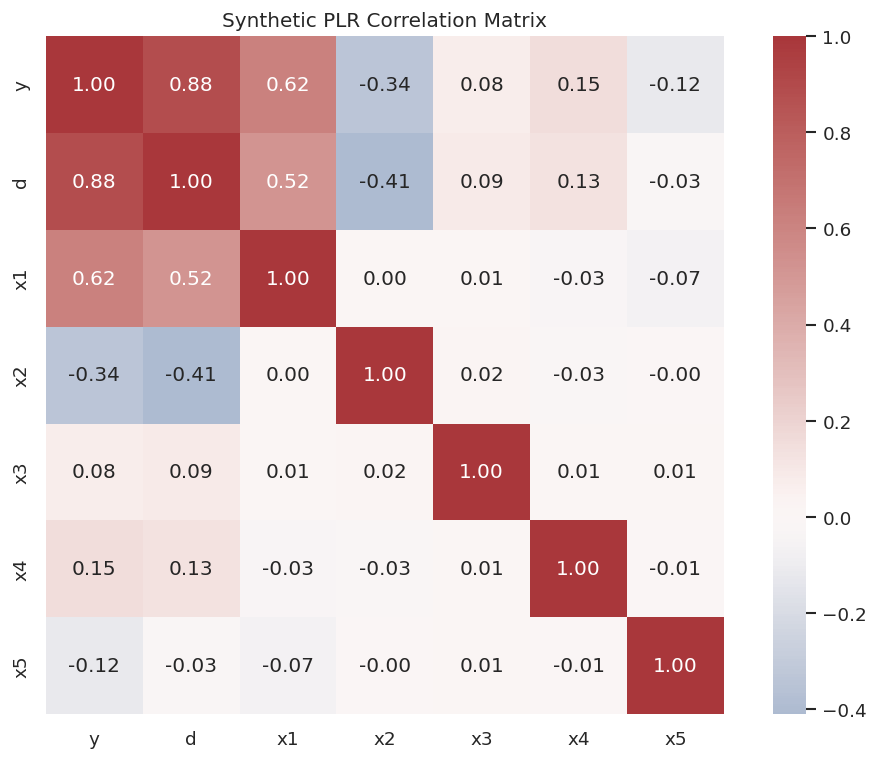

In [11]:
correlation_matrix = plr_df.corr(numeric_only=True)
correlation_matrix.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_synthetic_plr_correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(correlation_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", square=True, ax=ax)
ax.set_title("Synthetic PLR Correlation Matrix")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_synthetic_plr_correlation_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

The treatment is correlated with several controls, and the outcome is correlated with both treatment and controls. That is the setting where a well-specified causal adjustment workflow matters.

## Cross-Fitting Intuition

Cross-fitting is easier to understand visually than verbally. In each fold, nuisance learners train on the training portion and predict nuisance values only for the held-out portion. After rotating across folds, every row has out-of-fold nuisance predictions.

The final causal estimate is then computed from those held-out nuisance predictions, not from in-sample predictions that could overfit each observation.

In [12]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
fold_rows = []
for fold_id, (train_idx, test_idx) in enumerate(kfold.split(plr_df), start=1):
    fold_rows.append(
        {
            "fold": fold_id,
            "train_rows": len(train_idx),
            "heldout_rows": len(test_idx),
            "heldout_share": len(test_idx) / len(plr_df),
        }
    )
fold_table = pd.DataFrame(fold_rows)
fold_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_cross_fitting_fold_sizes.csv", index=False)
display(fold_table)

,fold,train_rows,heldout_rows,heldout_share
0,1,960,240,0.2
1,2,960,240,0.2
2,3,960,240,0.2
3,4,960,240,0.2
4,5,960,240,0.2


Each row appears in a held-out fold exactly once for a single 5-fold split. DoubleML can also repeat sample splitting, which is covered later in the tutorial series.

The next figure shows the fold assignment for the first 80 rows. Dark cells are held-out rows for a given fold. Each column is one observation, and each row is one nuisance-training fold.

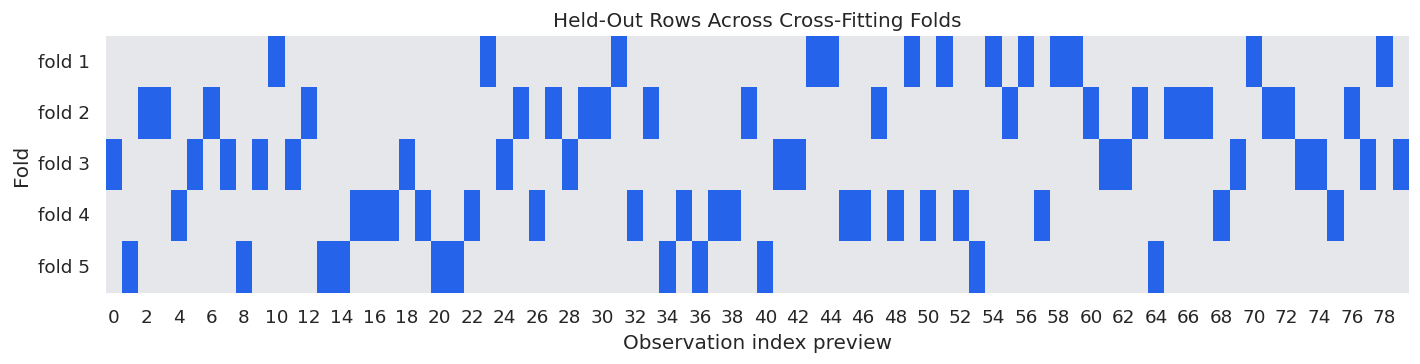

In [13]:
n_preview = 80
fold_matrix = np.zeros((5, n_preview), dtype=int)
for fold_id, (_, test_idx) in enumerate(kfold.split(plr_df), start=0):
    preview_test_idx = test_idx[test_idx < n_preview]
    fold_matrix[fold_id, preview_test_idx] = 1

fig, ax = plt.subplots(figsize=(12, 3.2))
sns.heatmap(
    fold_matrix,
    cmap=sns.color_palette(["#e5e7eb", "#2563eb"], as_cmap=True),
    cbar=False,
    linewidths=0.0,
    ax=ax,
)
ax.set_title("Held-Out Rows Across Cross-Fitting Folds")
ax.set_xlabel("Observation index preview")
ax.set_ylabel("Fold")
ax.set_yticklabels([f"fold {i}" for i in range(1, 6)], rotation=0)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_cross_fitting_preview.png", dpi=160, bbox_inches="tight")
plt.show()

The visual reinforces the core discipline: the row being scored is not used to train its nuisance prediction. That separation is one of the reasons DoubleML can use flexible learners while still supporting inference.

## A Minimal DoubleMLPLR Smoke Test

We now fit a small `DoubleMLPLR` model. In PLR, DoubleML needs:

- `ml_l`: learner for the outcome nuisance function, roughly predicting `Y` from `X`;
- `ml_m`: learner for the treatment nuisance function, roughly predicting `D` from `X`;
- a score, here `partialling out`;
- cross-fitting settings, here 5 folds and 1 repeated split.

The random forests below are intentionally modest so the notebook runs quickly.

In [14]:
ml_l = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
ml_m = clone(ml_l)

plr_model = dml.DoubleMLPLR(
    dml_data,
    ml_l=ml_l,
    ml_m=ml_m,
    n_folds=5,
    n_rep=1,
    score="partialling out",
)
print(plr_model)

================== DoubleMLPLR Object ==================

------------------ Data Summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['x1', 'x2', 'x3', 'x4', 'x5']
Instrument variable(s): None
No. Observations: 1200

------------------ Score & Algorithm ------------------
Score function: partialling out

------------------ Machine Learner   ------------------
Learner ml_l: RandomForestRegressor(max_depth=5, min_samples_leaf=8, n_jobs=-1,
                      random_state=42)
Learner ml_m: RandomForestRegressor(max_depth=5, min_samples_leaf=8, n_jobs=-1,
                      random_state=42)

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
Empty DataFrame
Columns: [coef, std err, t, P>|t|]
Index: []


Before fitting, the object summary already documents the data roles, score, learners, and resampling plan. This is useful because it catches mismatches before compute time is spent.

This cell fits the model and extracts the main estimate table. Since the data is synthetic, we also add the true effect and the estimation error.

In [15]:
TRUE_THETA = 1.50
plr_model.fit()

plr_summary = plr_model.summary.reset_index(names="treatment")
plr_summary["true_theta"] = TRUE_THETA
plr_summary["estimate_error"] = plr_summary["coef"] - TRUE_THETA
plr_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_plr_smoke_test_summary.csv", index=False)
display(plr_summary.round(4))

,treatment,coef,std err,t,P>|t|,2.5 %,97.5 %,true_theta,estimate_error
0,d,1.502,0.0296,50.7647,0.0,1.4441,1.56,1.5,0.002


The coefficient is close to the synthetic truth. In real applications, we do not know the truth, so the same table would be read together with uncertainty, design assumptions, sensitivity checks, and diagnostics.

## Naive Baselines Versus DoubleML

A good library tour should show what DoubleML is protecting us from. The next cell compares three estimates:

- naive regression of `Y` on `D` only;
- linear regression of `Y` on `D` and the raw controls;
- DoubleML PLR with flexible nuisance models and cross-fitting.

The first baseline ignores confounding. The second adjusts linearly but cannot fully match the nonlinear data-generating process. DoubleML uses flexible learners for the nuisance functions while targeting a low-dimensional causal parameter.

In [16]:
naive_model = LinearRegression().fit(plr_df[["d"]], plr_df["y"])
linear_adjusted_model = LinearRegression().fit(plr_df[["d"] + x_cols], plr_df["y"])

comparison_table = pd.DataFrame(
    [
        {
            "method": "naive_y_on_d",
            "estimate": float(naive_model.coef_[0]),
            "absolute_error_vs_truth": abs(float(naive_model.coef_[0]) - TRUE_THETA),
            "uses_controls": False,
            "uses_cross_fitting": False,
        },
        {
            "method": "linear_adjusted_y_on_d_plus_x",
            "estimate": float(linear_adjusted_model.coef_[0]),
            "absolute_error_vs_truth": abs(float(linear_adjusted_model.coef_[0]) - TRUE_THETA),
            "uses_controls": True,
            "uses_cross_fitting": False,
        },
        {
            "method": "doubleml_plr_random_forest_nuisance",
            "estimate": float(plr_model.coef[0]),
            "absolute_error_vs_truth": abs(float(plr_model.coef[0]) - TRUE_THETA),
            "uses_controls": True,
            "uses_cross_fitting": True,
        },
    ]
)
comparison_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_naive_vs_doubleml_estimates.csv", index=False)
display(comparison_table.round(4))

,method,estimate,absolute_error_vs_truth,uses_controls,uses_cross_fitting
0,naive_y_on_d,1.7958,0.2958,False,False
1,linear_adjusted_y_on_d_plus_x,1.4919,0.0081,True,False
2,doubleml_plr_random_forest_nuisance,1.5020,0.0020,True,True


The contrast shows the purpose of the package. DoubleML is not trying to beat every prediction benchmark; it is using prediction tools to estimate a causal effect with reduced nuisance-induced bias.

The plot below places the estimates next to the true synthetic effect. This style of plot is useful in tutorials and simulations because it makes bias visible. In real data, the vertical truth line would be unavailable.

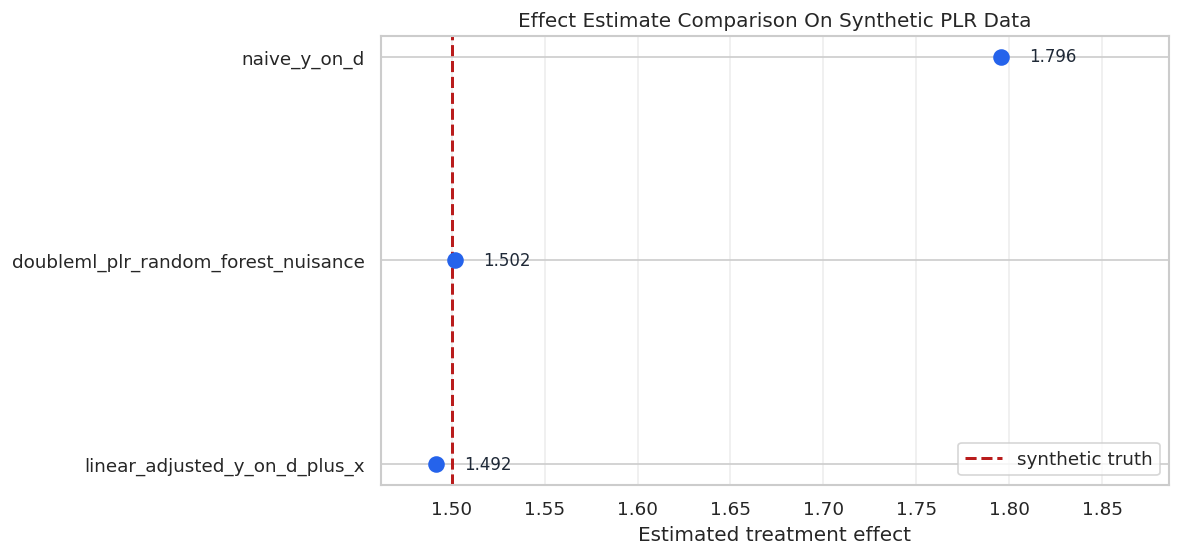

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df = comparison_table.sort_values("estimate").reset_index(drop=True)

ax.scatter(plot_df["estimate"], plot_df.index, s=80, color="#2563eb", zorder=3)
for row in plot_df.itertuples(index=True):
    ax.text(row.estimate + 0.015, row.Index, f"{row.estimate:.3f}", va="center", fontsize=10, color="#1f2937")

x_min = min(plot_df["estimate"].min(), TRUE_THETA) - 0.03
x_max = max(plot_df["estimate"].max(), TRUE_THETA) + 0.09
ax.set_xlim(x_min, x_max)
ax.axvline(TRUE_THETA, color="#b91c1c", linestyle="--", linewidth=1.8, label="synthetic truth")
ax.set_yticks(plot_df.index)
ax.set_yticklabels(plot_df["method"])
ax.set_title("Effect Estimate Comparison On Synthetic PLR Data")
ax.set_xlabel("Estimated treatment effect")
ax.set_ylabel("")
ax.legend(loc="lower right")
ax.grid(True, axis="x", alpha=0.35)
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_naive_vs_doubleml_estimates.png", dpi=160, bbox_inches="tight")
plt.show()

The DoubleML estimate lands close to the synthetic truth in this run. The naive estimate is visibly inflated because treatment assignment is confounded by controls that also affect the outcome.

## Nuisance Predictions And Losses

DoubleML stores nuisance predictions and nuisance losses. These are not the final causal result, but they help diagnose whether the nuisance learners are doing something reasonable. Bad nuisance models can still damage finite-sample performance even when the score is orthogonal.

In [18]:
nuisance_loss_rows = []
for learner_name, loss_array in plr_model.nuisance_loss.items():
    nuisance_loss_rows.append(
        {
            "learner_role": learner_name,
            "loss_value": float(np.asarray(loss_array).ravel()[0]),
            "loss_type": "mean squared error for this regression learner",
        }
    )
nuisance_loss_table = pd.DataFrame(nuisance_loss_rows)
nuisance_loss_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_plr_nuisance_losses.csv", index=False)
display(nuisance_loss_table.round(4))

,learner_role,loss_value,loss_type
0,ml_l,1.9513,mean squared error for this regression learner
1,ml_m,1.0762,mean squared error for this regression learner


The two nuisance losses summarize how well the learners predicted the outcome nuisance and treatment nuisance. They are useful diagnostics, but lower nuisance loss does not automatically mean a better causal estimate; the causal score and identification assumptions still matter.

The next cell extracts out-of-fold nuisance predictions and compares them with the observed variables. This gives a quick check that the nuisance learners learned meaningful signal rather than returning nearly constant predictions.

In [19]:
pred_l = np.asarray(plr_model.predictions["ml_l"]).squeeze()
pred_m = np.asarray(plr_model.predictions["ml_m"]).squeeze()

prediction_quality = pd.DataFrame(
    [
        {
            "nuisance_role": "ml_l predicts y from x",
            "rmse": mean_squared_error(plr_df["y"], pred_l) ** 0.5,
            "r2": r2_score(plr_df["y"], pred_l),
        },
        {
            "nuisance_role": "ml_m predicts d from x",
            "rmse": mean_squared_error(plr_df["d"], pred_m) ** 0.5,
            "r2": r2_score(plr_df["d"], pred_m),
        },
    ]
)
prediction_quality.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_plr_nuisance_prediction_quality.csv", index=False)
display(prediction_quality.round(4))

,nuisance_role,rmse,r2
0,ml_l predicts y from x,1.9513,0.5426
1,ml_m predicts d from x,1.0762,0.4223


The nuisance models capture real signal, especially for treatment assignment. That makes sense because the synthetic treatment equation was generated from controls. Later notebooks will spend much more time on learner choice and tuning.

This scatter plot visualizes observed versus out-of-fold predicted nuisance values. The plots are diagnostic aids, not final causal evidence.

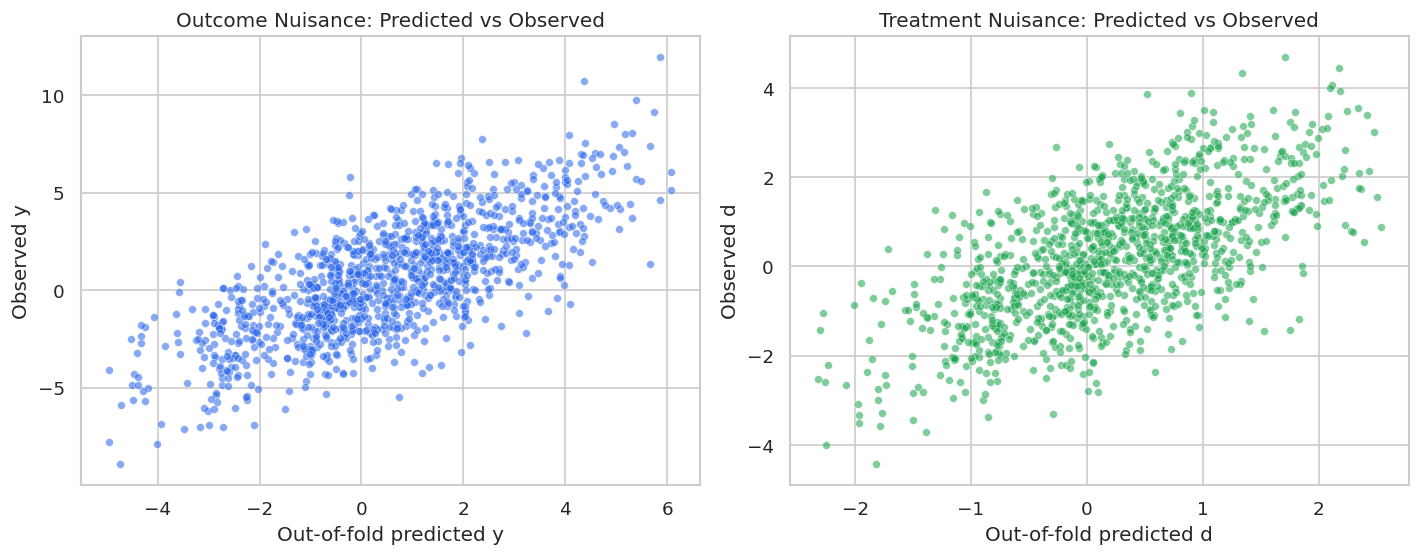

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.scatterplot(x=pred_l, y=plr_df["y"], s=22, alpha=0.55, color="#2563eb", ax=axes[0])
axes[0].set_title("Outcome Nuisance: Predicted vs Observed")
axes[0].set_xlabel("Out-of-fold predicted y")
axes[0].set_ylabel("Observed y")

sns.scatterplot(x=pred_m, y=plr_df["d"], s=22, alpha=0.55, color="#16a34a", ax=axes[1])
axes[1].set_title("Treatment Nuisance: Predicted vs Observed")
axes[1].set_xlabel("Out-of-fold predicted d")
axes[1].set_ylabel("Observed d")

plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_plr_nuisance_prediction_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

The treatment nuisance has a clearer relationship because treatment assignment was strongly driven by controls. The outcome nuisance is harder because the outcome also contains the treatment effect and noise.

## Built-In Dataset Functions

This installed DoubleML version exposes dataset fetch helpers. We will list them and save their signatures, but we will not fetch data in this first notebook. Keeping the first tutorial offline-friendly makes it more reliable for students and for automated notebook execution.

In [21]:
dataset_functions = []
for name in dir(dml_datasets):
    if name.startswith("fetch_"):
        obj = getattr(dml_datasets, name)
        try:
            signature = str(inspect.signature(obj))
        except (TypeError, ValueError):
            signature = "signature not available"
        first_doc_line = (inspect.getdoc(obj) or "").splitlines()[0] if inspect.getdoc(obj) else ""
        dataset_functions.append(
            {
                "function": name,
                "signature": signature,
                "doc_summary": first_doc_line,
                "used_in_this_notebook": False,
            }
        )

dataset_function_table = pd.DataFrame(dataset_functions)
dataset_function_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_dataset_fetch_functions.csv", index=False)
display(dataset_function_table)

,function,signature,doc_summary,used_in_this_notebook
0,fetch_401K,"(return_type='DoubleMLData', polynomial_featur...",Data set on financial wealth and 401(k) plan p...,False
1,fetch_bonus,"(return_type='DoubleMLData', polynomial_featur...",Data set on the Pennsylvania Reemployment Bonu...,False


The fetch helpers are useful for examples, but synthetic data is better for this opening notebook because we can know the true effect and show what DoubleML is recovering.

## What DoubleML Does And Does Not Do

This is the most important conceptual boundary in the notebook. DoubleML can make effect estimation more robust to nuisance-model complexity, but it cannot repair a bad design. The table below separates package responsibilities from analyst responsibilities.

In [22]:
responsibility_table = pd.DataFrame(
    [
        {
            "task": "Define the causal question",
            "main_owner": "analyst",
            "doubleml_role": "None directly; the package fits models after the question is specified.",
        },
        {
            "task": "Choose an identification strategy",
            "main_owner": "analyst",
            "doubleml_role": "Provides model classes for several strategies, but does not validate assumptions by itself.",
        },
        {
            "task": "Assign variable roles",
            "main_owner": "analyst",
            "doubleml_role": "Stores roles in data backend objects and uses them during fitting.",
        },
        {
            "task": "Estimate nuisance functions",
            "main_owner": "DoubleML plus supplied learners",
            "doubleml_role": "Clones learners, fits cross-fitted nuisance models, and stores predictions/losses.",
        },
        {
            "task": "Solve orthogonal score",
            "main_owner": "DoubleML",
            "doubleml_role": "Computes target estimates using model-specific orthogonal moments.",
        },
        {
            "task": "Quantify uncertainty",
            "main_owner": "DoubleML",
            "doubleml_role": "Reports standard errors, confidence intervals, p-values, and bootstrap tools where available.",
        },
        {
            "task": "Write credible conclusions",
            "main_owner": "analyst",
            "doubleml_role": "Supplies estimates and diagnostics that must be reported with design caveats.",
        },
    ]
)
responsibility_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_responsibility_table.csv", index=False)
display(responsibility_table)

,task,main_owner,doubleml_role
0,Define the causal question,analyst,None directly; the package fits models after t...
1,Choose an identification strategy,analyst,"Provides model classes for several strategies,..."
2,Assign variable roles,analyst,Stores roles in data backend objects and uses ...
3,Estimate nuisance functions,DoubleML plus supplied learners,"Clones learners, fits cross-fitted nuisance mo..."
4,Solve orthogonal score,DoubleML,Computes target estimates using model-specific...
5,Quantify uncertainty,DoubleML,"Reports standard errors, confidence intervals,..."
6,Write credible conclusions,analyst,Supplies estimates and diagnostics that must b...


The analyst owns the design. DoubleML owns a lot of the estimation mechanics. The best work keeps both responsibilities visible.

## Tutorial Series Roadmap

The remaining notebooks turn this overview into a full hands-on sequence. This roadmap is written as a practical learning path: start with theory and data roles, then core model families, then inference, diagnostics, advanced APIs, and an end-to-end case study.

In [23]:
tutorial_roadmap = pd.DataFrame(
    [
        {"notebook": "00_environment_and_library_tour.ipynb", "theme": "Orientation", "main_skill": "Understand what DoubleML is for and run a first PLR smoke test."},
        {"notebook": "01_dml_theory_orthogonalization_and_cross_fitting.ipynb", "theme": "Theory", "main_skill": "Understand regularization bias, orthogonal scores, and cross-fitting."},
        {"notebook": "02_data_backend_doublemldata_and_design_setup.ipynb", "theme": "Data setup", "main_skill": "Create data containers and audit variable roles."},
        {"notebook": "03_partially_linear_regression_plr.ipynb", "theme": "PLR", "main_skill": "Estimate continuous-treatment effects with DoubleMLPLR."},
        {"notebook": "04_partially_linear_iv_pliv.ipynb", "theme": "IV", "main_skill": "Use instruments for continuous treatments with DoubleMLPLIV."},
        {"notebook": "05_interactive_regression_model_irm.ipynb", "theme": "Binary treatment", "main_skill": "Estimate ATE and ATT-style effects with DoubleMLIRM."},
        {"notebook": "06_interactive_iv_model_iivm.ipynb", "theme": "Binary IV", "main_skill": "Estimate instrument-induced local effects with DoubleMLIIVM."},
        {"notebook": "07_difference_in_differences_did.ipynb", "theme": "DID", "main_skill": "Use DoubleML for before-after comparison designs."},
        {"notebook": "08_sample_selection_models.ipynb", "theme": "Selection", "main_skill": "Handle outcomes observed only for selected samples."},
        {"notebook": "09_regression_discontinuity_design_rdd.ipynb", "theme": "RDD", "main_skill": "Structure cutoff-based local effect estimation."},
        {"notebook": "10_learners_hyperparameters_and_tuning.ipynb", "theme": "Learners", "main_skill": "Choose and tune nuisance learners without leakage."},
        {"notebook": "11_sample_splitting_cross_fitting_and_repeated_cross_fitting.ipynb", "theme": "Resampling", "main_skill": "Control sample splits and repeated cross-fitting."},
        {"notebook": "12_inference_bootstrap_and_confidence_bands.ipynb", "theme": "Inference", "main_skill": "Report uncertainty, confidence intervals, and bootstrap results."},
        {"notebook": "13_sensitivity_analysis_for_unobserved_confounding.ipynb", "theme": "Sensitivity", "main_skill": "Assess hidden-confounding robustness where supported."},
        {"notebook": "14_heterogeneous_treatment_effects_gate_cate_blp.ipynb", "theme": "Heterogeneity", "main_skill": "Report subgroup and conditional effect summaries."},
        {"notebook": "15_policy_learning_weighted_ates_quantiles_and_cvar.ipynb", "theme": "Decision targets", "main_skill": "Work with weighted, policy, quantile, and tail-risk causal targets."},
        {"notebook": "16_custom_scores_and_advanced_api.ipynb", "theme": "Advanced API", "main_skill": "Understand custom scores and extension patterns."},
        {"notebook": "17_common_pitfalls_diagnostics_and_reporting.ipynb", "theme": "Pitfalls", "main_skill": "Diagnose overlap, leakage, weak instruments, and bad controls."},
        {"notebook": "18_end_to_end_doubleml_case_study.ipynb", "theme": "Case study", "main_skill": "Combine the full workflow into a final report."},
    ]
)
tutorial_roadmap.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_tutorial_roadmap.csv", index=False)
display(tutorial_roadmap)

,notebook,theme,main_skill
0,00_environment_and_library_tour.ipynb,Orientation,Understand what DoubleML is for and run a firs...
1,01_dml_theory_orthogonalization_and_cross_fitt...,Theory,"Understand regularization bias, orthogonal sco..."
2,02_data_backend_doublemldata_and_design_setup....,Data setup,Create data containers and audit variable roles.
3,03_partially_linear_regression_plr.ipynb,PLR,Estimate continuous-treatment effects with Dou...
4,04_partially_linear_iv_pliv.ipynb,IV,Use instruments for continuous treatments with...
5,05_interactive_regression_model_irm.ipynb,Binary treatment,Estimate ATE and ATT-style effects with Double...
6,06_interactive_iv_model_iivm.ipynb,Binary IV,Estimate instrument-induced local effects with...
7,07_difference_in_differences_did.ipynb,DID,Use DoubleML for before-after comparison designs.
8,08_sample_selection_models.ipynb,Selection,Handle outcomes observed only for selected sam...
9,09_regression_discontinuity_design_rdd.ipynb,RDD,Structure cutoff-based local effect estimation.


The next natural notebook is the theory notebook. It will slow down on orthogonality and cross-fitting so the package mechanics feel motivated rather than magical.

## Starter Report Checklist

Even a first smoke test should end with a reporting checklist. This keeps the tutorial grounded in applied causal analysis rather than pure package mechanics.

In [24]:
starter_report_checklist = pd.DataFrame(
    [
        {"check": "Causal question stated", "status_in_this_notebook": "synthetic PLR effect of d on y", "why_it_matters": "The target parameter must be clear before fitting."},
        {"check": "Variable roles defined", "status_in_this_notebook": "y, d, x1-x5 dictionary saved", "why_it_matters": "Data-role mistakes change the analysis."},
        {"check": "Identification assumptions stated", "status_in_this_notebook": "PLR synthetic design with controls sufficient by construction", "why_it_matters": "DoubleML estimation still relies on design assumptions."},
        {"check": "Nuisance learners documented", "status_in_this_notebook": "random forest settings printed and saved through model object", "why_it_matters": "Learner choices affect finite-sample behavior."},
        {"check": "Cross-fitting documented", "status_in_this_notebook": "5-fold cross-fitting preview saved", "why_it_matters": "Out-of-fold nuisance prediction is central to DML."},
        {"check": "Estimate and uncertainty reported", "status_in_this_notebook": "PLR summary table saved", "why_it_matters": "A point estimate without uncertainty is incomplete."},
        {"check": "Limitations stated", "status_in_this_notebook": "synthetic truth available only because this is a tutorial", "why_it_matters": "Real analyses do not get a known true effect."},
    ]
)
starter_report_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_starter_report_checklist.csv", index=False)
display(starter_report_checklist)

,check,status_in_this_notebook,why_it_matters
0,Causal question stated,synthetic PLR effect of d on y,The target parameter must be clear before fitt...
1,Variable roles defined,"y, d, x1-x5 dictionary saved",Data-role mistakes change the analysis.
2,Identification assumptions stated,PLR synthetic design with controls sufficient ...,DoubleML estimation still relies on design ass...
3,Nuisance learners documented,random forest settings printed and saved throu...,Learner choices affect finite-sample behavior.
4,Cross-fitting documented,5-fold cross-fitting preview saved,Out-of-fold nuisance prediction is central to ...
5,Estimate and uncertainty reported,PLR summary table saved,A point estimate without uncertainty is incomp...
6,Limitations stated,synthetic truth available only because this is...,Real analyses do not get a known true effect.


This checklist is small now, but the later notebooks will expand it with overlap diagnostics, sensitivity analysis, learner tuning, sample splitting uncertainty, and design-specific checks.

## Reusable Analysis Template

The last substantive output is a small markdown template. It gives students a simple structure for writing up a DoubleML result without skipping the design assumptions.

In [25]:
analysis_template = """# DoubleML Analysis Template

## 1. Causal Question

State the treatment, outcome, target population, and intended estimand.

## 2. Identification Strategy

State the design: unconfoundedness, IV, DID, RDD, sample selection, or another setup. List the assumptions needed for the estimate to be causal.

## 3. Data Roles

List outcome columns, treatment columns, controls, instruments, time variables, cluster variables, sample-selection variables, and excluded variables.

## 4. Nuisance Learners

Document each nuisance learner, its role, preprocessing, tuning approach, and whether tuning was nested safely.

## 5. Cross-Fitting And Resampling

Report folds, repeated splits, random seed, external split logic, and any clustered or temporal split decisions.

## 6. Main Estimate

Report coefficient or effect estimate, standard error, confidence interval, p-value, and estimand meaning.

## 7. Diagnostics

Include nuisance losses, overlap or propensity diagnostics where relevant, sensitivity checks, and split robustness.

## 8. Caveats And Next Steps

State what the estimate does not prove, what assumptions are hardest to defend, and what validation or follow-up design should come next.
"""

report_path = REPORT_DIR / f"{NOTEBOOK_PREFIX}_doubleml_analysis_template.md"
report_path.write_text(analysis_template)
print(report_path)

/home/apex/Documents/ranking_sys/notebooks/tutorials/doubleml/outputs/reports/00_doubleml_analysis_template.md


The template is intentionally compact. It keeps the final communication centered on the causal design, not just the package output.

## Artifact Manifest

The final cell records the files created by this notebook. The manifest is a simple audit trail for reproducibility.

In [26]:
artifact_paths = sorted(
    list(DATASET_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(TABLE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(FIGURE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(REPORT_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
)
artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": path.parent.name,
            "path": str(path.relative_to(OUTPUT_DIR)),
            "size_kb": round(path.stat().st_size / 1024, 2),
        }
        for path in artifact_paths
    ]
)
artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
display(artifact_manifest)

,artifact_type,path,size_kb
0,datasets,datasets/00_synthetic_plr_data.csv,139.51
1,figures,figures/00_cross_fitting_preview.png,42.16
2,figures,figures/00_doubleml_workflow.png,68.37
3,figures,figures/00_naive_vs_doubleml_estimates.png,59.88
4,figures,figures/00_plr_nuisance_prediction_scatter.png,283.01
5,figures,figures/00_synthetic_plr_correlation_matrix.png,95.98
6,reports,reports/00_doubleml_analysis_template.md,1.17
7,tables,tables/00_artifact_manifest.csv,1.22
8,tables,tables/00_core_class_signatures.csv,3.91
9,tables,tables/00_cross_fitting_fold_sizes.csv,0.11


## Closing Notes

The main takeaway is that DoubleML is an estimation framework for causal designs with flexible nuisance learning. The theory protects the target parameter from first-stage prediction mistakes, but it does not remove the need for careful design.

The next notebook will go deeper into the core theory: regularization bias, orthogonal scores, sample splitting, and cross-fitting.